<a href="https://colab.research.google.com/github/finn-mcduffee8/IT480-FA26/blob/main/Copy_of_Lab2_CNN_PetFinder_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: CNN for Image Classification (PetFinder)

**Name:** Carter Moorefield and Finn McDuffee

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

## Setup

Clone the course repo (or your fork) to access the dataset, then import the libraries you expect to need. You will likely want `pandas`, `numpy`, `os`, image-loading tools (for example `PIL.Image`), `matplotlib`, `tensorflow`, and evaluation tools from `sklearn`. Add imports as you go, you don't need to guess all of them up front.

In [2]:
# Clone the repo to access the data (only needs to run once per Colab session)
# !git clone https://github.com/moorefcj/IT480-FA26


In [3]:
# Your imports here



---
## Part A: Load and Prepare the Data

**What to do:**
1. Load `train.csv` and inspect it. You need the `PetID` and `Type` columns (`Type`: 1 = Dog, 2 = Cat).
2. Write code that loads each pet's primary photo from `train_images/`, resizes it to a consistent size of your choosing, and normalizes pixel values.
3. Build your `X` (images) and `y` (Dog/Cat) arrays.
4. Split into train and test sets. Decide, and justify, whether you need to stratify this split.
5. Report how many images you ended up with, and whether Dog and Cat are reasonably balanced.

**Note:** not every `PetID` in `train.csv` will have a matching photo file. Your loading code should skip missing images gracefully rather than erroring out.

**Answer in this notebook:**
- What image size did you choose, and why?
We used an image size of 28x28 pixels since it is the original size of the Fashion-MNIST images.
- Did you stratify your train/test split? Why or why not?
We did not manyally stratify the train and test split since Fashion-MNIST already provides training and testing datasets.

In [4]:
# Load train.csv here
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical


In [5]:
# Write your image-loading function here
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# Build X and y, then split into train/test here
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


*Your written answers for Part A:*

- Image size chosen and why:
- Stratification decision and why:


---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?
- What output layer and activation fits a Dog vs. Cat task specifically? Is this the same as Lab 1's binary classification setup, or different?

Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

We used two Conv2D layers with two MaxPooling2D layers. The first convolutional layer uses 32 filters and the second uses 64. This allows the model to learn more complex features as it goes deeper. We used 3x3 kernels because they are effective at identifying small spatial features in images. We had a pool_size of 2 in the MaxPooling to reduce the size of the feature maps while keeping the most important information. Next we used a flatten layer, which converted feature maps into a form that can be passed to the classifier. Lastly the dense layer has 10 neurons. The softmax activation produces a probability for each class, so we went with softmax since this dataset contains 10 possible classes.

In [7]:
# Build your CNN model here
model = Sequential()

model.add(Conv2D(32, kernel_size = 3, activation= 'relu', input_shape = (28, 28, 1)))
model.add(MaxPooling2D(pool_size = 2, strides = 2))

model.add(Conv2D(64, kernel_size= 3, activation= 'relu'))
model.add(MaxPooling2D(pool_size = 2, strides = 2))

model.add(Flatten())

model.add(Dense(10, activation= 'softmax'))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
#Compile your model here
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"])

*Your architecture justification (one paragraph):*




---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [9]:
# Train your model here (save the result as `history`)
history = model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.8184 - loss: 0.5049 - val_accuracy: 0.8660 - val_loss: 0.3741
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - accuracy: 0.8768 - loss: 0.3441 - val_accuracy: 0.8842 - val_loss: 0.3302
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 75s 30ms/step - accuracy: 0.8895 - loss: 0.3048 - val_accuracy: 0.8881 - val_loss: 0.3087
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - accuracy: 0.8996 - loss: 0.2746 - val_accuracy: 0.8863 - val_loss: 0.3059
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 32ms/step - accuracy: 0.9074 - loss: 0.2518 - val_accuracy: 0.8978 - val_loss: 0.2828
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9139 - loss: 0.2342 - val_accuracy: 0.9038 - val_loss: 0.2678
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9207 - loss: 0.2163 - val_accuracy: 0.9024 - val_loss: 0.2672
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9258 -

In [10]:
# Plot training vs. validation loss and accuracy here
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")

        plt.tight_layout()
        plt.show()

    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()




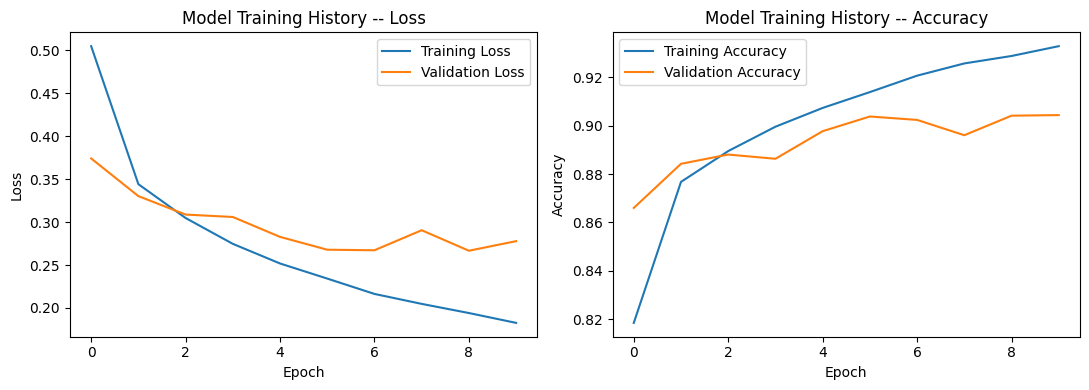

In [11]:
plot_history(
    history,
    "Model Training History",
    show_accuracy=True
)

*Your fit diagnosis, with specific evidence from your curve:*
The model showed signs of overfitting. At first both training and validation improved, but after 3 epochs while the training loss continued to improve the validation did not. Training accuracy also continued to improve after 3 epochs while validation almost stayed around 90-91%. The model is learning training data more without improving on unseen data.



In [12]:
# Evaluate on the test set and report accuracy here

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy: {test_accuracy:.4f}')


Test accuracy: 0.8982


---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

In [13]:
# We believe our model was overfitting the data, so we plan to apply Dropout to our model.

*Which path are you taking, and why:*




In [20]:
# Dropout
improved_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, kernel_size=3, activation='relu',
                           input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),

    tf.keras.layers.Conv2D(64, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),

    tf.keras.layers.Conv2D(128, kernel_size=3, activation='relu'),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
improved_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

improved_history = improved_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.7954 - loss: 0.5673 - val_accuracy: 0.8622 - val_loss: 0.3744
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - accuracy: 0.8731 - loss: 0.3528 - val_accuracy: 0.8888 - val_loss: 0.3041
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 37ms/step - accuracy: 0.8910 - loss: 0.3018 - val_accuracy: 0.8940 - val_loss: 0.2874
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.9014 - loss: 0.2699 - val_accuracy: 0.8894 - val_loss: 0.2884
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 37ms/step - accuracy: 0.9084 - loss: 0.2440 - val_accuracy: 0.9021 - val_loss: 0.2722
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.9180 - loss: 0.2217 - val_accuracy: 0.9022 - val_loss: 0.2636
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 37ms/step - accuracy: 0.9268 - loss: 0.1986 - val_accuracy: 0.9083 - val_loss: 0.2625
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 38ms/step - accuracy: 0.9307 -

In [23]:
test_loss, test_accuracy = improved_model.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy: {test_accuracy:.4f}')

Test accuracy: 0.9081


---
## Part E: Compare and Evaluate

Fill in your own results:

| | Baseline CNN | Improved CNN |
|---|---|---|
| Test accuracy | 0.9044 | 0.9081 |
| Fit pattern (good/over/under) | Over | Slight over |
| What changed | | Accuracy increased by 0.37 percentage points |

Report a confusion matrix for your improved model. Are Dogs or Cats more often misclassified? Do you have a guess as to why, based on looking at a few misclassified photos directly?

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


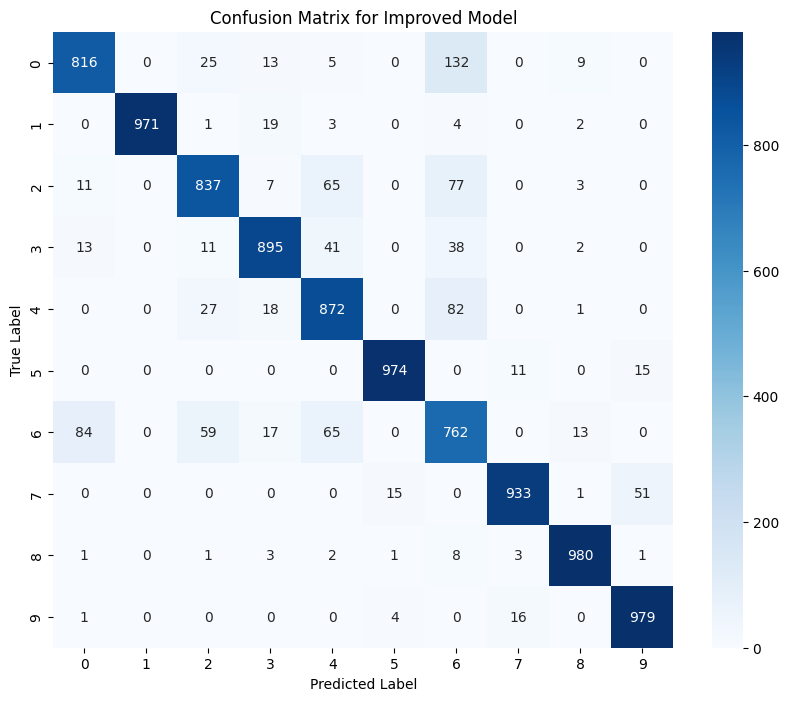

In [18]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate the improved model (already done in previous cell xf9Yuoc0I6Ln, but re-evaluating for clarity)
# test_loss, test_accuracy = improved_model.evaluate(x_test, y_test, verbose=0)
# print(f'Improved Model Test Accuracy: {test_accuracy:.4f}')

# Get predictions for the test set
y_pred_proba = improved_model.predict(x_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

# Build the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Improved Model')
plt.show()

\*Your discussion of the confusion matrix:*
The improved CNN acheived a test accuracy of 90.81%, which is 0.37% higher from the baseline CNN. Looking at the confusion matrix, T-shirts/tops and shirts were most commonly confused. 132 T-shirt/top images were classified as shirts. This likely happens since clothing items can have similar shapes and features.



---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
Total misclassified images: 919


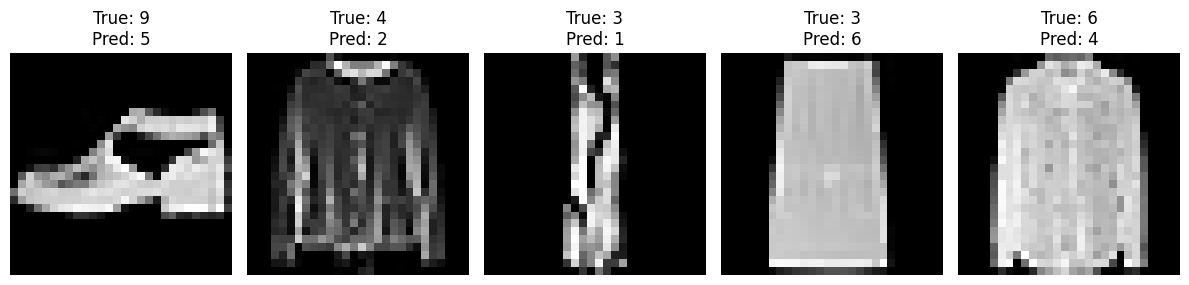

In [24]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

y_pred_proba = improved_model.predict(x_test)
y_pred = np.argmax(y_pred_proba, axis=1)

misclassified_indices = np.where(y_pred != y_true)[0]

print(f"Total misclassified images: {len(misclassified_indices)}")

num_display = min(5, len(misclassified_indices))

plt.figure(figsize=(12, 3))

for i, idx in enumerate(misclassified_indices[:num_display]):
    plt.subplot(1, num_display, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_true[idx]}\nPred: {y_pred[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

*Your observations about the misclassified images:*
Many of the misclassified images look very simalar to the class they were predicted as. A lot of the clothing items have a similar shape and texture which makes it hard for the CNN to distinguish.



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.